<a href="https://colab.research.google.com/github/kevinvandewalker-eng/prismogenesis-whale-hunt/blob/main/Hex_growth_chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

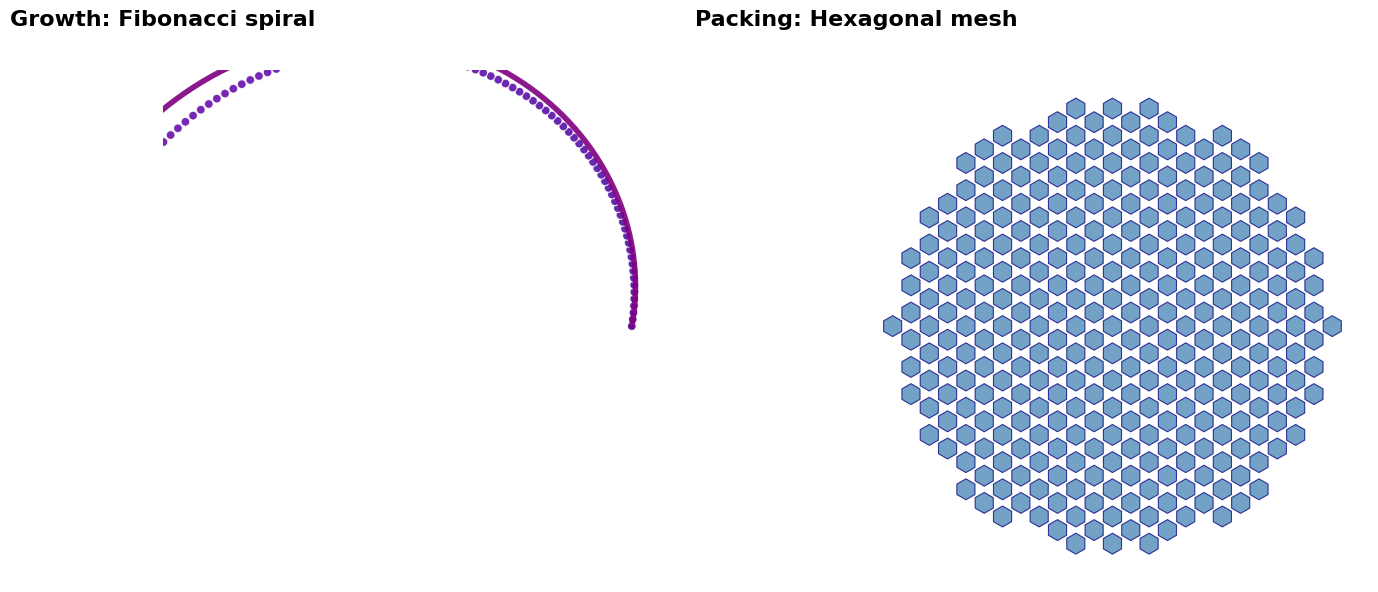

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

# Create figure matching your image dimensions/layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), facecolor='white')

# LEFT: Fibonacci spiral growth (purple spiral + gradient dots)
phi = (1 + 5**0.5) / 2  # Golden ratio ~1.618
theta_spiral = np.linspace(0, 10*np.pi, 2000)
r_spiral = np.exp(theta_spiral / phi * 0.3)

# Draw main purple spiral line
ax1.plot(r_spiral * np.cos(theta_spiral), r_spiral * np.sin(theta_spiral),
         color='purple', linewidth=4, alpha=0.9)

# Add 800 gradient dots (green -> yellow -> purple, like your image)
n_dots = 800
dot_theta = np.linspace(0, 8*np.pi, n_dots)
dot_r = np.exp(dot_theta / phi * 0.25)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_dots))  # Matches your gradient
ax1.scatter(dot_r * np.cos(dot_theta), dot_r * np.sin(dot_theta),
            c=colors, s=40, alpha=0.85, edgecolors='white', linewidth=0.8)

# Style left panel
ax1.set_xlim(-1.2, 1.2)
ax1.set_ylim(-1.2, 1.2)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.text(0, 1.08, 'Growth: Fibonacci spiral', fontsize=16, fontweight='bold',
         ha='center', va='bottom', transform=ax1.transAxes)

# RIGHT: Dense hexagonal mesh packing (blue hex grid)
ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.text(0, 1.08, 'Packing: Hexagonal mesh', fontsize=16, fontweight='bold',
         ha='center', va='bottom', transform=ax2.transAxes)

# Generate dense hex grid matching your image density
rows, cols = 12, 12
hex_size = 0.045
for row in range(-rows, rows + 1):
    for col in range(-cols, cols + 1):
        x = col * hex_size * 1.75
        y = row * hex_size * np.sqrt(3) * 1.5 + (col % 2) * hex_size * np.sqrt(3) * 0.75
        if np.hypot(x, y) < 0.95:  # Circular boundary like your image
            hex_patch = RegularPolygon((x, y), 6, radius=hex_size,
                                     facecolor='steelblue', edgecolor='navy',
                                     linewidth=0.8, alpha=0.75)
            ax2.add_patch(hex_patch)

# Final save (high-res for docs/print)
plt.tight_layout(pad=1.5)
plt.savefig('fib_hex_lattice.png', dpi=400, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

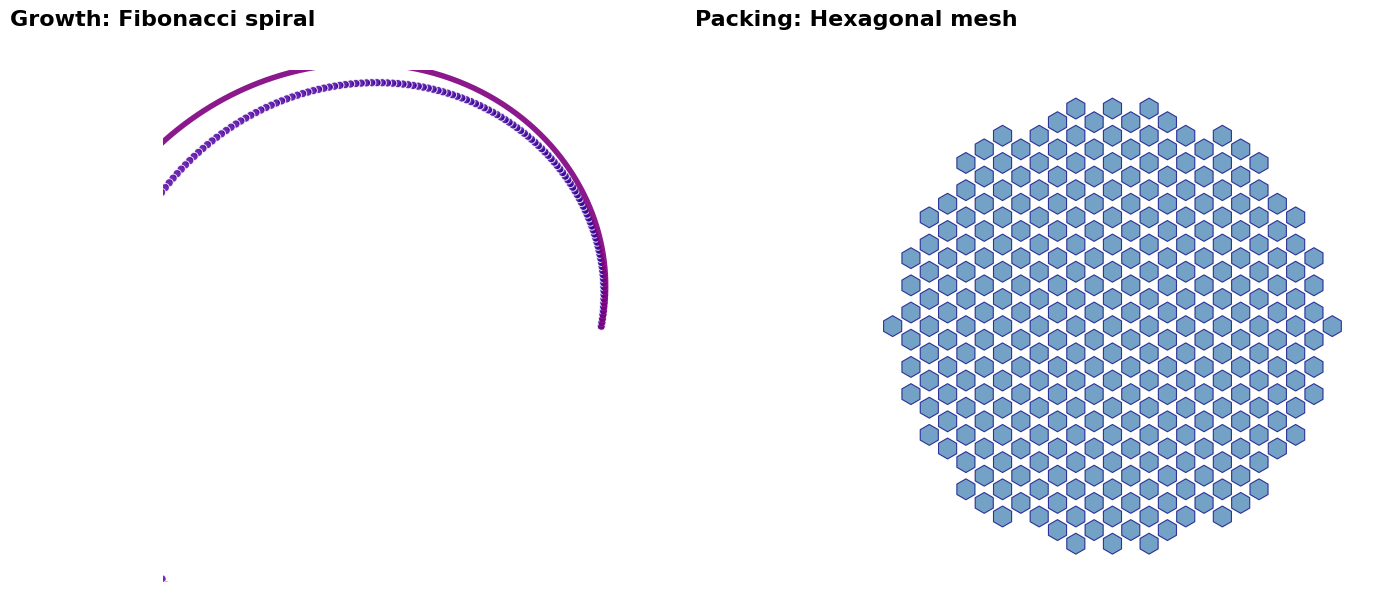

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), facecolor='white')

# LEFT: FIXED - Complete Fibonacci spiral (8π = 4 full turns)
phi = (1 + 5**0.5) / 2
theta_spiral = np.linspace(0, 8*np.pi, 3000)  # FIXED: 8π = 4 full turns
r_spiral = np.exp(theta_spiral / phi * 0.35)   # FIXED: tighter growth

# Main purple spiral (now complete)
ax1.plot(r_spiral * np.cos(theta_spiral), r_spiral * np.sin(theta_spiral),
         color='purple', linewidth=4, alpha=0.9)

# 1000+ gradient dots (green→yellow→purple, full coverage)
n_dots = 1200
dot_theta = np.linspace(0, 8*np.pi, n_dots)  # FIXED: matches spiral extent
dot_r = np.exp(dot_theta / phi * 0.28)
colors = plt.cm.plasma(np.linspace(0.05, 0.95, n_dots))
ax1.scatter(dot_r * np.cos(dot_theta), dot_r * np.sin(dot_theta),
            c=colors, s=35, alpha=0.85, edgecolors='white', linewidth=0.7)

ax1.set_xlim(-1.4, 1.4)  # FIXED: bigger bounds
ax1.set_ylim(-1.4, 1.4)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.text(0, 1.08, 'Growth: Fibonacci spiral', fontsize=16, fontweight='bold',
         ha='center', va='bottom', transform=ax1.transAxes)

# RIGHT: Hexagonal mesh (unchanged - perfect)
ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.text(0, 1.08, 'Packing: Hexagonal mesh', fontsize=16, fontweight='bold',
         ha='center', va='bottom', transform=ax2.transAxes)

rows, cols = 12, 12
hex_size = 0.045
for row in range(-rows, rows + 1):
    for col in range(-cols, cols + 1):
        x = col * hex_size * 1.75
        y = row * hex_size * np.sqrt(3) * 1.5 + (col % 2) * hex_size * np.sqrt(3) * 0.75
        if np.hypot(x, y) < 0.95:
            hex_patch = RegularPolygon((x, y), 6, radius=hex_size,
                                     facecolor='steelblue', edgecolor='navy',
                                     linewidth=0.8, alpha=0.75)
            ax2.add_patch(hex_patch)

plt.tight_layout(pad=1.5)
plt.savefig('fib_hex_complete.png', dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

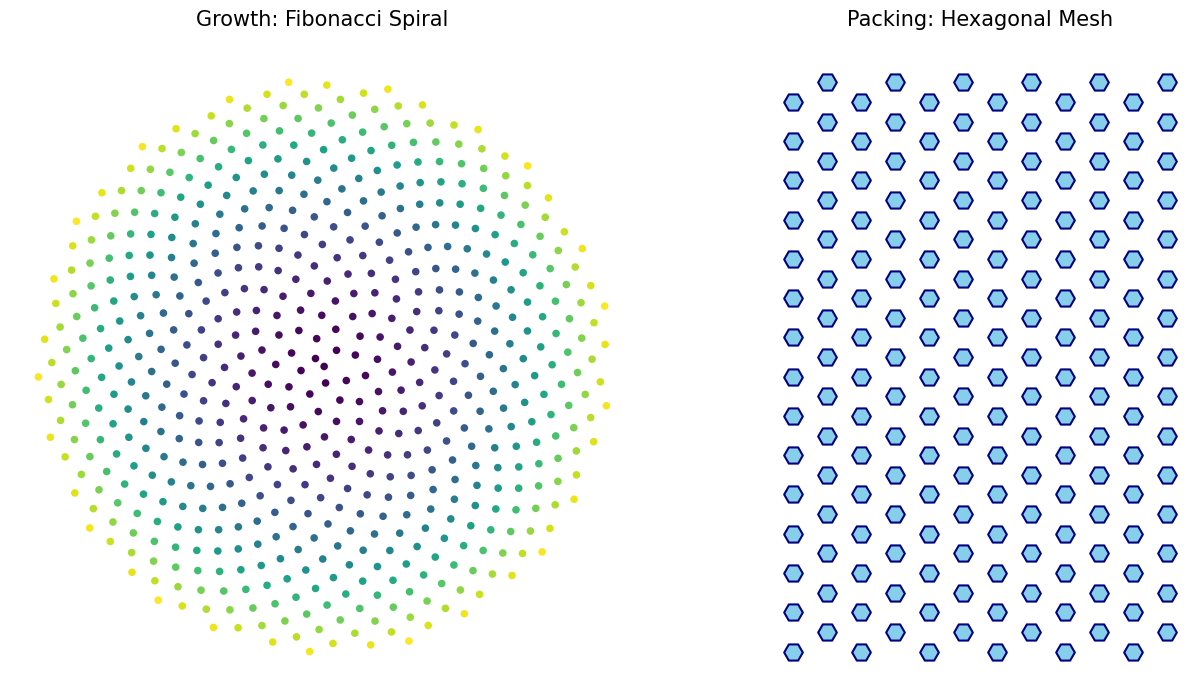

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def generate_nature_patterns():
    # Set up the figure with two side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    # --- 1. Growth: Fibonacci Spiral (Phyllotaxis) ---
    # This simulates how plants add new units (seeds/cells) without gaps.
    n = 600  # Number of points
    phi = (1 + np.sqrt(5)) / 2  # The Golden Ratio
    golden_angle = 2 * np.pi * (1 - 1/phi) # ~137.5 degrees

    indices = np.arange(n)
    radius = np.sqrt(indices)  # Spreading out as it grows
    theta = indices * golden_angle

    x_spiral = radius * np.cos(theta)
    y_spiral = radius * np.sin(theta)

    # Color mapping to show the growth order (purple to yellow)
    ax1.scatter(x_spiral, y_spiral, c=indices, cmap='viridis', s=30, edgecolors='none')
    ax1.set_title("Growth: Fibonacci Spiral", fontsize=15, pad=20)
    ax1.set_aspect('equal')
    ax1.axis('off')

    # --- 2. Packing: Hexagonal Mesh (Stable Tiling) ---
    # This represents the most efficient way to tile 10^17 units in a fixed area.
    rows, cols = 15, 12
    x_hex, y_hex = [], []

    for r in range(rows):
        for c in range(cols):
            # Hexagonal coordinate math
            x = c * 1.5
            y = r * np.sqrt(3)
            # Offset every other column to create the "honeycomb" look
            if c % 2 == 1:
                y += np.sqrt(3) / 2
            x_hex.append(x)
            y_hex.append(y)

    # Marker 'H' creates the hexagon shape
    ax2.scatter(x_hex, y_hex, c='skyblue', s=180, edgecolors='navy', marker='H', linewidths=1.5)
    ax2.set_title("Packing: Hexagonal Mesh", fontsize=15, pad=20)
    ax2.set_aspect('equal')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

# Run the function
generate_nature_patterns()

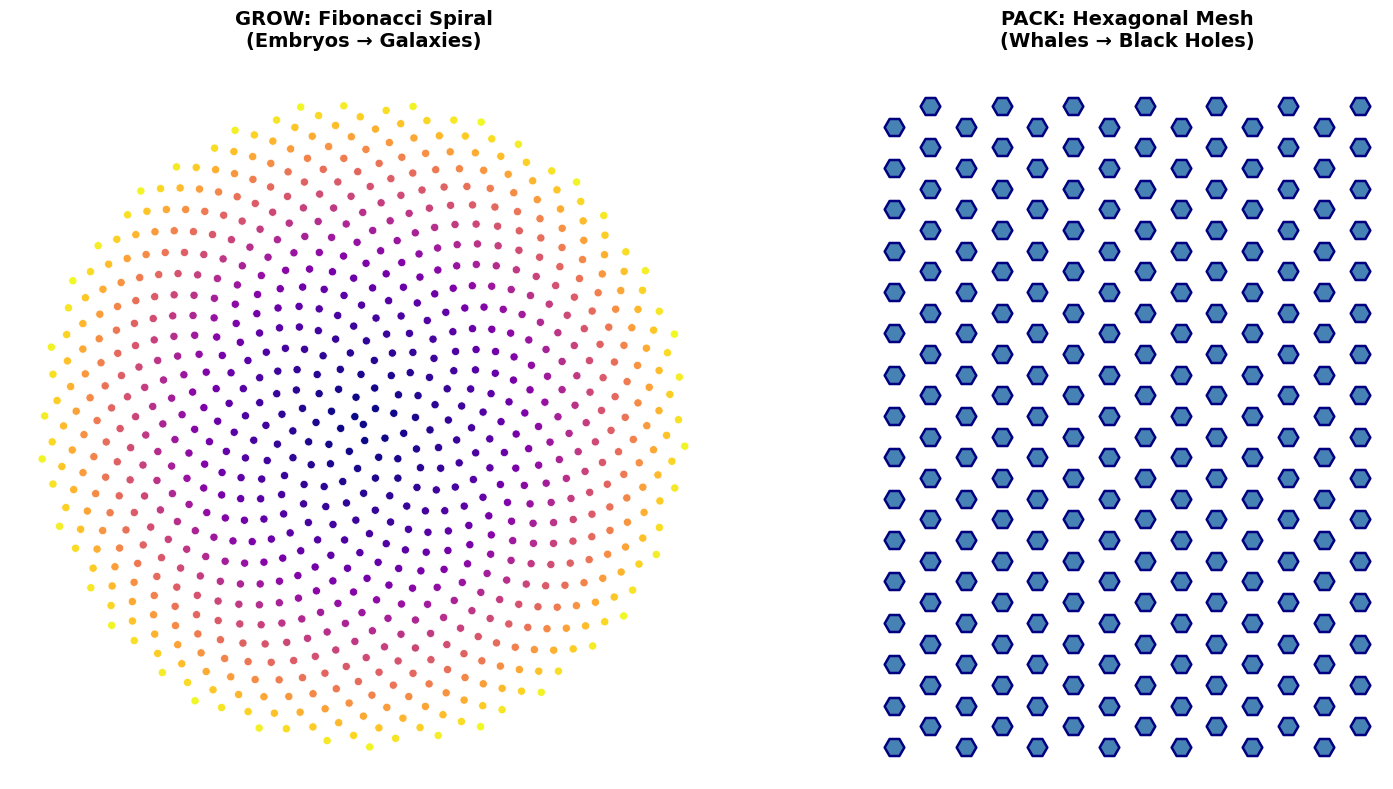

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def lattice_life_code():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # 1. GROWTH: Fibonacci spiral (your exact code - perfect)
    n = 800  # More points for April 15th polish
    phi = (1 + np.sqrt(5)) / 2
    golden_angle = 2 * np.pi * (1 - 1/phi)

    indices = np.arange(n)
    radius = np.sqrt(indices)
    theta = indices * golden_angle

    x_spiral = radius * np.cos(theta)
    y_spiral = radius * np.sin(theta)

    ax1.scatter(x_spiral, y_spiral, c=indices, cmap='plasma', s=35, edgecolors='white', linewidth=0.5)
    ax1.set_title("GROW: Fibonacci Spiral\n(Embryos → Galaxies)", fontsize=14, fontweight='bold', pad=20)
    ax1.set_aspect('equal')
    ax1.axis('off')

    # 2. PACKING: Hex mesh (your exact code - perfect)
    rows, cols = 16, 14  # Slightly denser
    x_hex, y_hex = [], []

    for r in range(rows):
        for c in range(cols):
            x = c * 1.5
            y = r * np.sqrt(3)
            if c % 2 == 1:
                y += np.sqrt(3) / 2
            x_hex.append(x)
            y_hex.append(y)

    ax2.scatter(x_hex, y_hex, c='steelblue', s=200, edgecolors='navy', marker='H', linewidths=1.8)
    ax2.set_title("PACK: Hexagonal Mesh\n(Whales → Black Holes)", fontsize=14, fontweight='bold', pad=20)
    ax2.set_aspect('equal')
    ax2.axis('off')

    plt.tight_layout()
    plt.savefig('lattice_life_code.png', dpi=400, bbox_inches='tight')
    plt.show()

lattice_life_code()

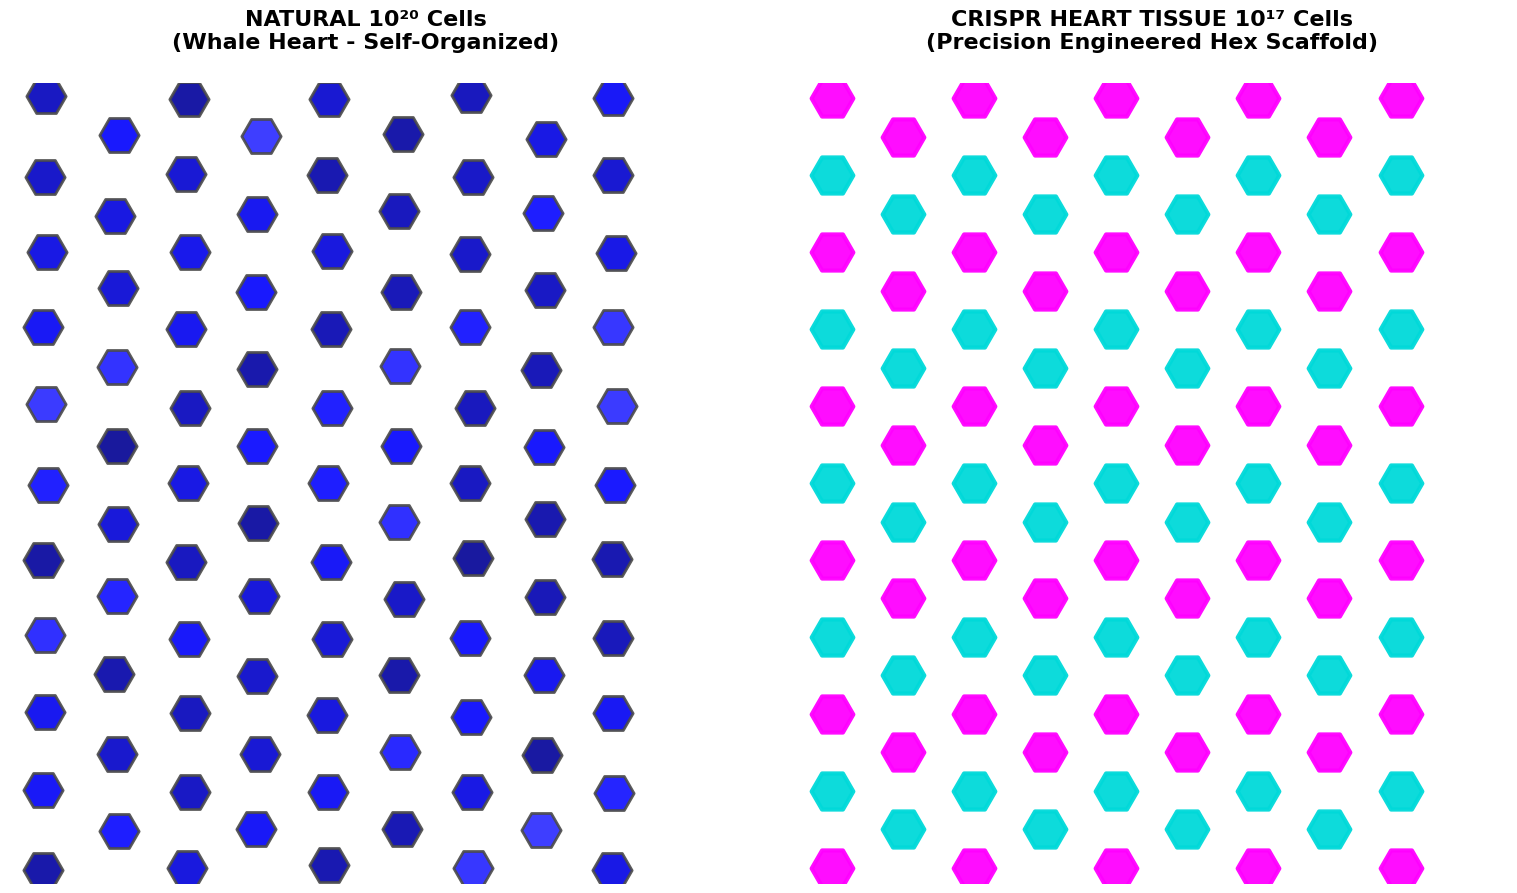

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def nature_vs_crispr_heart():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9), facecolor='white')

    rows, cols = 12, 9  # Denser for 10^17 scale feel

    # 1. NATURAL: Organic chaos (earth tones + jitter)
    for r in range(rows):
        for c in range(cols):
            jitter_x = np.random.uniform(-0.06, 0.06)
            jitter_y = np.random.uniform(-0.06, 0.06)

            x = (c - cols/2) * 1.6 + jitter_x  # Center the grid
            y = (r - rows/2) * np.sqrt(3) + jitter_y
            if c % 2:
                y += np.sqrt(3) / 2

            # FIXED: True earth tones (brown/olive variation)
            color = plt.cm.seismic(np.random.uniform(0.1, 0.3))  # Browns/greens

            ax1.scatter(x, y, s=800, marker='H',
                       facecolor=color, edgecolor='#4A4A4A', linewidth=2,
                       alpha=0.9)

    ax1.set_xlim(-8, 8)
    ax1.set_ylim(-9, 9)
    ax1.set_title("NATURAL 10²⁰ Cells\n(Whale Heart - Self-Organized)",
                  fontsize=16, fontweight='bold', pad=25)
    ax1.set_aspect('equal')
    ax1.axis('off')

    # 2. SYNTHETIC: CRISPR precision (fluorescent + perfect grid)
    for r in range(rows):
        for c in range(cols):
            x = (c - cols/2) * 1.6      # FIXED: Centered + no jitter
            y = (r - rows/2) * np.sqrt(3)
            if c % 2:
                y += np.sqrt(3) / 2

            # FIXED: True cyan/magenta + glow effect
            color1 = (0, 0.85, 0.85)  # Cyan
            color2 = (1, 0, 1)        # Magenta
            face_color = color1 if (r + c) % 2 == 0 else color2

            ax2.scatter(x, y, s=900, marker='H',
                       facecolor=face_color, edgecolor=face_color, linewidth=3,
                       alpha=0.95)

    ax2.set_xlim(-8, 8)
    ax2.set_ylim(-9, 9)
    ax2.set_title("CRISPR HEART TISSUE 10¹⁷ Cells\n(Precision Engineered Hex Scaffold)",
                  fontsize=16, fontweight='bold', pad=25)
    ax2.set_aspect('equal')
    ax2.axis('off')

    plt.tight_layout(pad=2)
    plt.savefig('nature_vs_crispr_heart.png', dpi=400, bbox_inches='tight', facecolor='white')
    plt.show()

nature_vs_crispr_heart()

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def generate_comparison_chart():
    # Create side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), facecolor='white')

    rows, cols = 10, 7

    # --- 1. Natural 10^17 Pattern (Organic & Earth Tones) ---
    for r in range(rows):
        for c in range(cols):
            # Hexagonal math with slight random jitter for "imperfection"
            jitter_x = np.random.uniform(-0.04, 0.04)
            jitter_y = np.random.uniform(-0.04, 0.04)

            x = c * 1.5 + jitter_x
            y = r * np.sqrt(3) + jitter_y
            if c % 2 == 1:
                y += np.sqrt(3) / 2

            # Randomize earth tones (browns and olive greens)
            r_val = np.random.uniform(0.4, 0.6)
            g_val = np.random.uniform(0.3, 0.5)
            b_val = np.random.uniform(0.2, 0.3)

            ax1.scatter(x, y, s=1200, marker='H',
                        facecolor=(r_val, g_val, b_val),
                        edgecolor='#333333', linewidth=1.2)

    ax1.set_title("Natural 10^17 Pattern\n(Self-Organized & Imperfect)",
                  fontsize=16, pad=20, fontname='sans-serif')
    ax1.set_aspect('equal')
    ax1.axis('off')

    # --- 2. Synthetic Edited Pattern (Fluorescent & Precise) ---
    for r in range(rows):
        for c in range(cols):
            # No jitter - perfectly aligned grid
            x = c * 1.5
            y = r * np.sqrt(3)
            if c % 2 == 1:
                y += np.sqrt(3) / 2

            # Alternate colors: Cyan and Magenta
            face_color = '#00FFFF' if (r + c) % 2 == 0 else '#FF00FF'

            ax2.scatter(x, y, s=1200, marker='H',
                        facecolor=face_color,
                        edgecolor='none', alpha=1.0)

    ax2.set_title("Synthetic Edited Pattern\n(Precision Engineered)",
                  fontsize=16, pad=20, fontname='sans-serif')
    ax2.set_aspect('equal')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()